# ML - REGRESION LINEAL REGULARIZADA (MODELO)

In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils2 import get_metrics
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV, RidgeCV, ElasticNet

## Paso 1: Lectura del conjunto de datos de entrenamiento y prueba procesados

In [2]:
with open('../data/processed/03-X_train_sel.pkl', 'rb') as f:
    X_train_sel = pickle.load(f)
with open('../data/processed/03-X_test_sel.pkl', 'rb') as f:
    X_test_sel = pickle.load(f)
with open('../data/processed/03-y_train.pkl', 'rb') as f:
    y_train = pickle.load(f)
with open('../data/processed/03-y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)
 
X_test_sel

,fips,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,...,Percent of Population Aged 60+,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,Obesity_prevalence,COPD_prevalence,diabetes_prevalence,CKD_prevalence,Urban_rural_code
COUNTY_NAME,,,,,,,,,,,,,,,,,,,,,
Durham,0.655149,0.031335,0.477817,0.509226,0.428968,0.646095,0.603191,0.428480,0.292039,0.112769,...,0.195205,0.654545,0.073897,0.031684,0.337104,0.432277,0.141975,0.235897,0.227273,0.4
Fairfield,0.800051,0.002208,0.385539,0.487679,0.304759,0.249890,0.516433,0.689429,0.541659,0.250601,...,0.378425,0.800000,0.045292,0.002276,0.647059,0.746398,0.401235,0.671795,0.613636,0.4
Saline,0.293656,0.002357,0.466432,0.510847,0.307297,0.347575,0.547296,0.564827,0.410010,0.226494,...,0.347603,0.290909,0.195471,0.002354,0.610860,0.593660,0.456790,0.358974,0.454545,1.0
Monona,0.329409,0.000850,0.450733,0.542375,0.268039,0.235841,0.452414,0.536284,0.447792,0.261901,...,0.450342,0.327273,0.157330,0.000843,0.583710,0.605187,0.302469,0.333333,0.431818,1.0
Emporia,0.919156,0.000498,0.372745,0.599958,0.338363,0.342544,0.525694,0.537584,0.352889,0.218790,...,0.291096,0.909091,0.707986,0.000499,0.773756,0.780980,0.493827,0.728205,0.750000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Dyer,0.836494,0.003684,0.497899,0.579842,0.328574,0.339862,0.588884,0.542330,0.348549,0.202758,...,0.279110,0.836364,0.052443,0.003575,0.660633,0.587896,0.475309,0.441026,0.409091,0.8
King,0.858731,0.000019,0.524629,0.573171,0.269051,0.450314,0.402095,0.578871,0.431168,0.135182,...,0.090753,0.854545,0.319428,0.000015,0.522624,0.512968,0.265432,0.302564,0.318182,1.0
Franklin,0.346232,0.002528,0.492658,0.607218,0.317250,0.359226,0.535686,0.599052,0.369904,0.177773,...,0.273973,0.345455,0.069130,0.002457,0.590498,0.648415,0.253086,0.282051,0.250000,0.8


## Paso 2: Modelo de regresión lineal

In [4]:
# Modelo base
lr_model = LinearRegression()

# Entrenamiento
lr_model.fit(X_train_sel, y_train)

# Predicción
lr_y_pred_train = lr_model.predict(X_train_sel)
lr_y_pred_test = lr_model.predict(X_test_sel)

# Métricas
get_metrics(lr_y_pred_test, y_test, lr_y_pred_train, y_train)

,R2,MAE,MAPE,MSE,RMSE
Train set,0.982146,0.144281,2.208688,0.055688,0.235982
Test set,0.980205,0.154591,2.272476,0.058964,0.242825
Difference,-0.001941,0.010311,0.063788,0.003276,0.006842


In [5]:
#Guardamos el modelo
with open('../models/03-linregmodel', 'wb') as f:
    pickle.dump(lr_model, f)

> ## Conclusiones
>
> - El modelo tiene muy buena precion (98%) por lo que entendemos que es muy poco probable optimizarlo más
> - No tenemos overfiting, predice bien tanto el y_test como el y_train

### LassoCV

In [6]:
r2_scores = []
for i in range(0,21):
    lasso_model = Lasso(alpha=i, max_iter=400, random_state=21)  # modelo
    lasso_model.fit(X_train_sel, y_train)  # entrenamiento

    lasso_y_pred_test = lasso_model.predict(X_test_sel)  # Predicción en test
    lasso_y_pred_train = lasso_model.predict(X_train_sel)  # Predicción en train
    results = get_metrics(lasso_y_pred_test, y_test, lasso_y_pred_train, y_train)  # Métricas
    r2 = results.loc["Test set", "R2"]
    r2_scores.append((i,r2))

df_r2 = pd.DataFrame(r2_scores, columns=['alpha', 'R2'])
df_r2

/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py:1363: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.070e+01, tolerance: 7.835e-01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_co

,alpha,R2
0,0,0.980129
1,1,-0.001245
2,2,-0.001245
3,3,-0.001245
4,4,-0.001245
5,5,-0.001245
6,6,-0.001245
7,7,-0.001245
8,8,-0.001245
9,9,-0.001245


In [8]:
#Guardamos el modelo
with open('../models/03-lin-reg-model-lasso', 'wb') as f:
    pickle.dump(lasso_model, f)

Text(0.5, 1.0, 'Distribucion de alpha con R2 en modelo Lasso')

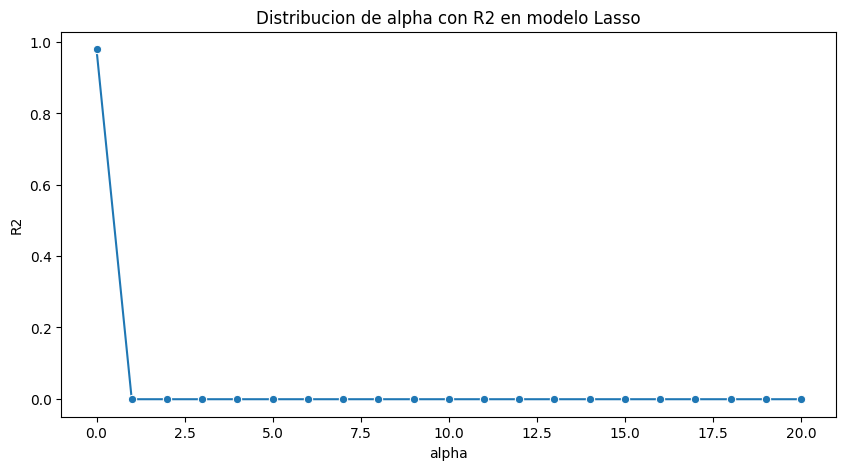

In [7]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_r2, x="alpha", y="R2", marker="o")
plt.title('Distribucion de alpha con R2 en modelo Lasso')

> ## Conclusiones
>
> - Con el modelo Lasso solamente obtenemos buenos resultados cuando alpha es 0, es decir cuando no hay penalizacion a los coeficientes. Esto tiene sentido ya que no tenemos Overfiting.
> - Al haber utilizado `MinMaxScaler` los coeficientes ya son pequeños y si los penalizamos además con `Lasso` los reduce a 0 y elimina variables importantes.
> - LLegamos a la conclusión final que el mejor modelo es el de regresión lineal sin aplicar Lasso `lr_model` ya que obtenemos mejores resultados (métricas)